In [219]:
import pandas as pd

In [220]:
data = pd.read_csv('globalterrorismdb_0718dist.csv', encoding='latin-1')

<ipython-input-220-e2176db862d2>:1: DtypeWarning: Columns (4,6,31,33,61,62,63,76,79,90,92,94,96,114,115,121) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('globalterrorismdb_0718dist.csv', encoding='latin-1')


In [221]:
data.head()

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,1.970000e+11,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,1.970000e+11,1970,1,1,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,1.970010e+11,1970,1,1,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,1.970010e+11,1970,1,1,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,1.970010e+11,1970,1,1,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN


In [222]:
pd.set_option('display.max_rows', None)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Columns: 135 entries, eventid to related
dtypes: float64(56), int64(21), object(58)
memory usage: 187.1+ MB


# **Missing data**

# **Printing columns that have less than 181691 values**

In [223]:
column_counts = data.count()
columns_with_nulls = column_counts[column_counts < 181691]

print(columns_with_nulls)

approxdate              9239
resolution              2220
provstate             181270
city                  181256
latitude              177135
longitude             177134
specificity           181685
location               55495
summary               115562
doubtterr             181690
alternative            29011
alternative_txt        29011
multiple              181690
attacktype2             6314
attacktype2_txt         6314
attacktype3              428
attacktype3_txt          428
targsubtype1          171318
targsubtype1_txt      171318
corp1                 139139
target1               181053
natlty1               180132
natlty1_txt           180132
targtype2              11144
targtype2_txt          11144
targsubtype2           10685
targsubtype2_txt       10685
corp2                  10117
target2                11020
natlty2                10828
natlty2_txt            10828
targtype3               1176
targtype3_txt           1176
targsubtype3            1097
targsubtype3_t

# **Dropping columns with less than 1000 values**

In [224]:
threshold = 10000
column_counts = data.count()
columns_to_drop = column_counts[column_counts < threshold].index

data = data.drop(columns=columns_to_drop)

print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Data columns (total 90 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   eventid             181691 non-null  float64
 1   iyear               181691 non-null  int64  
 2   imonth              181691 non-null  int64  
 3   iday                181691 non-null  int64  
 4   extended            181691 non-null  int64  
 5   country             181691 non-null  int64  
 6   country_txt         181691 non-null  object 
 7   region              181691 non-null  int64  
 8   region_txt          181691 non-null  object 
 9   provstate           181270 non-null  object 
 10  city                181256 non-null  object 
 11  latitude            177135 non-null  float64
 12  longitude           177134 non-null  float64
 13  specificity         181685 non-null  float64
 14  vicinity            181691 non-null  int64  
 15  location            55495 non-null

In [225]:
!pip install --upgrade pandas

In [226]:
import pandas as pd

try:
    # Read the CSV file with low_memory=False
    data = pd.read_csv('globalterrorismdb_0718dist.csv', encoding='latin-1', low_memory=False)

    # Replace 0 with 1 in 'iday' and 'imonth'
    data['iday'] = data['iday'].replace(0, 1)
    data['imonth'] = data['imonth'].replace(0, 1)

    # Convert date columns to datetime
    data['date'] = pd.to_datetime(data['iyear'].astype(str) + '-' + data['imonth'].astype(str) + '-' + data['iday'].astype(str), format='%Y-%m-%d', errors='coerce')

    # Drop the original date columns
    data.drop(['iyear', 'imonth', 'iday'], axis=1, inplace=True)

except ValueError as e:
    print(f"Error: {e}")


# Convert integer columns
int_cols = ['specificity', 'doubtterr', 'multiple', 'targsubtype1', 'natlty1', 'targtype2', 'targsubtype2', 'natlty2', 'guncertain1', 'nperps', 'nperpcap', 'claimed', 'claimmode', 'weapsubtype1', 'weaptype2', 'weapsubtype2', 'nkill', 'nkillus', 'nkillter', 'nwound', 'nwoundus', 'nwoundte', 'propextent', 'ishostkid', 'nhostkid', 'nhostkidus', 'ransom', 'hostkidoutcome', 'nreleased', 'vicinity']

for col in int_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce').fillna(0).astype('int64')

# Print DataFrame info
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Columns: 133 entries, eventid to date
dtypes: datetime64[ns](1), float64(27), int64(47), object(58)
memory usage: 184.4+ MB
None


In [227]:
#print first rows of column date
print(data['date'].head(20))

0    1970-07-02
1    1970-01-01
2    1970-01-01
3    1970-01-01
4    1970-01-01
5    1970-01-01
6    1970-01-02
7    1970-01-02
8    1970-01-02
9    1970-01-03
10   1970-01-01
11   1970-01-06
12   1970-01-08
13   1970-01-09
14   1970-01-09
15   1970-01-10
16   1970-01-11
17   1970-01-12
18   1970-01-12
19   1970-01-13
Name: date, dtype: datetime64[ns]


# **I created a new column of date joining year, month and day, but as we see it has 180800 values instead of 181691. This is because in the database there are month and days with value 0.**

# **Label encoder for categorical columns**

In [228]:
from sklearn.preprocessing import LabelEncoder


def label_encode_categorical(data):
    categorical_cols = data.select_dtypes(include=['object']).columns.tolist()
    for col in categorical_cols:
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col].astype(str))  # Convert to string to handle mixed values
    return data

# Apply label encoding
data = label_encode_categorical(data)

print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Columns: 133 entries, eventid to date
dtypes: datetime64[ns](1), float64(27), int64(105)
memory usage: 184.4 MB
None


# **We will take success as our target variable, meaning if the terror atack was done or not**

In [229]:
import seaborn as sns
import matplotlib.pyplot as plt

def calculate_correlation(data, target_col):
    return data.corr()[target_col].sort_values(ascending=False)


target_column = 'success'
correlation_values = calculate_correlation(data, target_column)
print(correlation_values)



success               1.000000
propextent            0.184092
targsubtype1          0.108574
weapsubtype4          0.107014
approxdate            0.102186
weapsubtype3          0.089678
attacktype3           0.086364
scite1                0.083882
hostkidoutcome        0.077263
extended              0.073233
weaptype3             0.064383
attacktype2           0.061879
INT_LOG               0.059875
INT_IDEO              0.059183
targsubtype3          0.057138
targtype3             0.052653
nkill                 0.049619
attacktype1           0.048408
summary               0.046504
ishostkid             0.044738
weaptype1_txt         0.041577
targsubtype2          0.038802
targtype2             0.038535
INT_ANY               0.038245
weapdetail            0.034261
weaptype2             0.032699
weapsubtype2          0.030334
nperps                0.027059
natlty2               0.025251
guncertain3           0.024859
guncertain1           0.024693
nwound                0.023346
claim2  

# **Calculating skewness and kurtosis to see in which columns we need to delete outliers**

In [230]:
import pandas as pd

def analyze_skewness_kurtosis(data, numerical_cols):
    """Analyzes skewness and kurtosis of numerical columns."""
    skewness = data[numerical_cols].skew()
    kurtosis = data[numerical_cols].kurtosis()
    analysis = pd.DataFrame({'Skewness': skewness, 'Kurtosis': kurtosis})
    return analysis

numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
skew_kurt_analysis = analyze_skewness_kurtosis(data, numerical_cols)

print(skew_kurt_analysis)

                      Skewness       Kurtosis
eventid              -0.619156      -1.042982
approxdate           -5.205948      27.221773
extended              4.370397      17.100559
resolution          -11.649246     143.150487
country               3.152161      15.032208
country_txt          -0.124886      -0.980281
region               -0.348260      -1.085662
region_txt           -0.430423      -0.177384
provstate             0.221877      -1.221292
city                 -0.007870      -1.307420
latitude             -0.963738       0.860664
longitude          -420.872852  177133.971789
specificity           2.159369       3.572100
vicinity             -3.789433     203.754597
location             -1.752784       1.755673
summary              -0.569846      -1.136603
crit1                -9.175880      82.197679
crit2               -11.907267     139.784540
crit3                -2.277071       3.185090
doubtterr            -3.074592       7.795052
alternative           2.951236    

# **Removing more columns, this time columns that are missing more than 70 percent of the data**

In [231]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=data
# 1. Remove columns with > 70% missing values
def remove_cols_missing_percentage(df, threshold=0.7):
    """Removes columns with a missing value percentage above the threshold."""
    cols_to_drop = []
    for col in df.columns:
        missing_percentage = df[col].isnull().sum() / len(df)
        if missing_percentage > threshold:
            cols_to_drop.append(col)
    df_cleaned = df.drop(cols_to_drop, axis=1)
    return df_cleaned

data_cleaned = remove_cols_missing_percentage(data)
print("DataFrame after removing columns with > 70% missing values:")
print(data_cleaned.info())


DataFrame after removing columns with > 70% missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Columns: 109 entries, eventid to date
dtypes: datetime64[ns](1), float64(3), int64(105)
memory usage: 151.1 MB
None


# **Normalizing and deleting outliers so we can check the correlation when the data is good for analysis**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Data columns (total 30 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   eventid             181691 non-null  float64       
 1   approxdate          181691 non-null  int64         
 2   extended            181691 non-null  int64         
 3   latitude            177135 non-null  float64       
 4   success             181691 non-null  int64         
 5   attacktype2         6314 non-null    float64       
 6   attacktype3         428 non-null     float64       
 7   targtype1           181691 non-null  int64         
 8   targtype1_txt       181691 non-null  int64         
 9   targsubtype1        181691 non-null  int64         
 10  targsubtype1_txt    181691 non-null  int64         
 11  target1             181691 non-null  int64         
 12  targtype3           1176 non-null    float64       
 13  targsubtype3        1097 non-

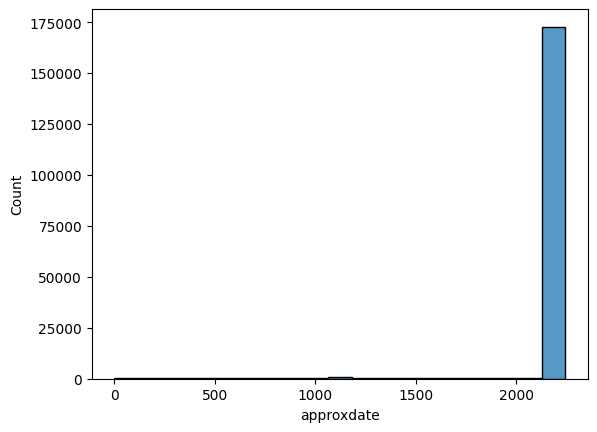

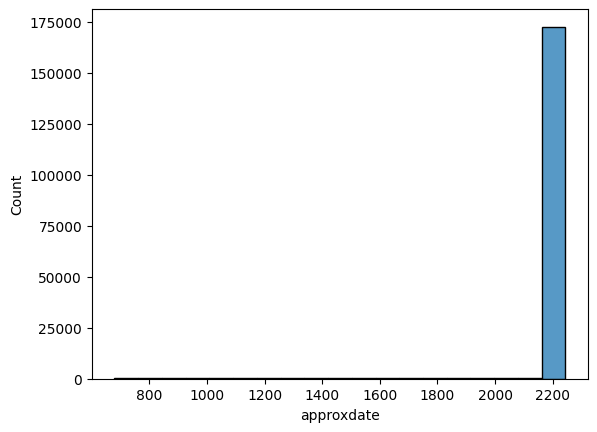

DataFrame size after cleaning column 'approxdate': 178713


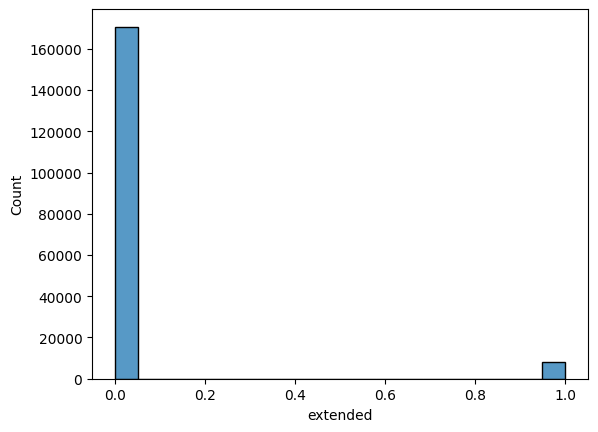

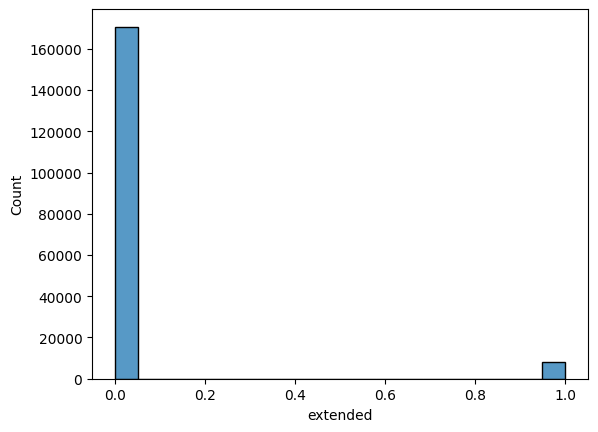

DataFrame size after cleaning column 'extended': 178713


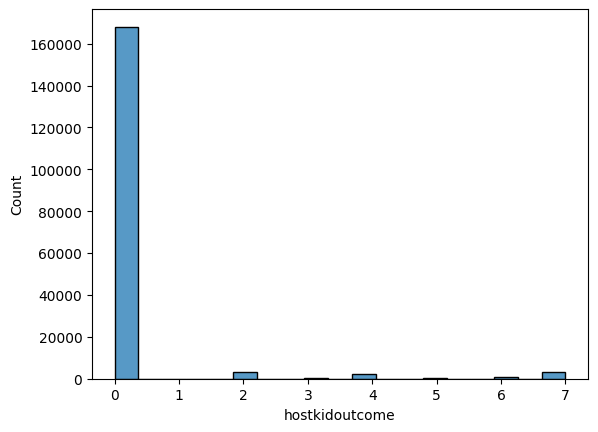

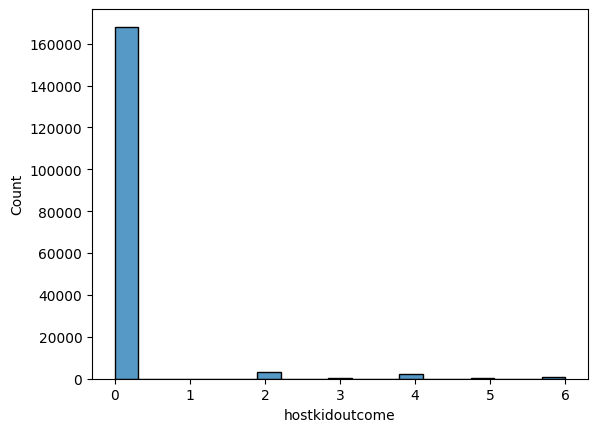

DataFrame size after cleaning column 'hostkidoutcome': 175304


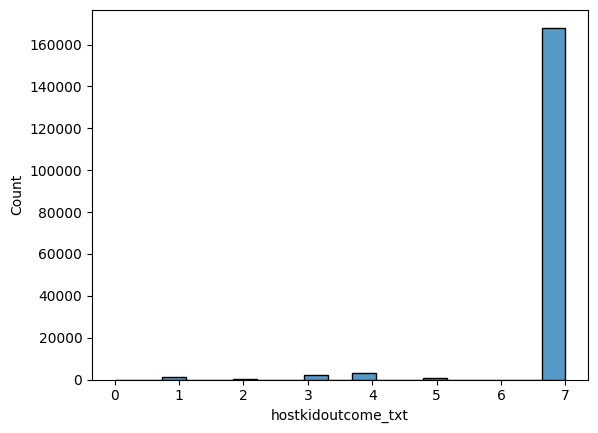

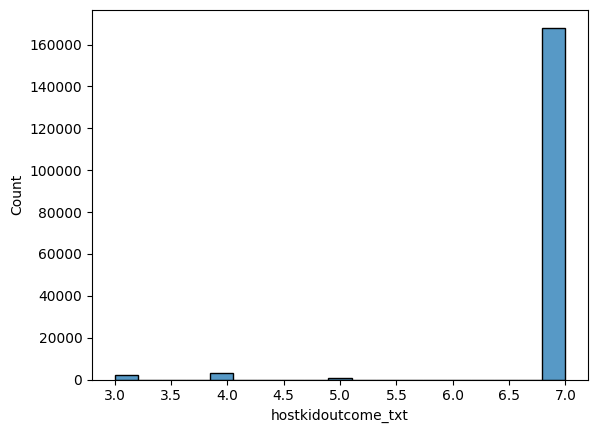

DataFrame size after cleaning column 'hostkidoutcome_txt': 174124
Final DataFrame size: 174124
DataFrame after normalization:
<class 'pandas.core.frame.DataFrame'>
Index: 174124 entries, 0 to 181690
Data columns (total 30 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   eventid             174124 non-null  float64       
 1   approxdate          174124 non-null  float64       
 2   extended            174124 non-null  float64       
 3   latitude            169734 non-null  float64       
 4   success             174124 non-null  float64       
 5   attacktype2         4948 non-null    float64       
 6   attacktype3         222 non-null     float64       
 7   targtype1           174124 non-null  float64       
 8   targtype1_txt       174124 non-null  float64       
 9   targsubtype1        174124 non-null  float64       
 10  targsubtype1_txt    174124 non-null  float64       
 11  target1             17

In [232]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

target_column = 'success'
correlation_values = data.corr()[target_column].sort_values(ascending=False)
correlation_threshold = 0.05
cols_to_drop = correlation_values[abs(correlation_values) < correlation_threshold].index.tolist()
data = data.drop(cols_to_drop, axis=1)
print(f"DataFrame after dropping low-correlation columns: {data.info()}")

numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
skewness = data[numerical_cols].skew()
kurtosis = data[numerical_cols].kurtosis()
high_skew_kurt_cols = skewness[(abs(skewness) > 3) | (abs(kurtosis) > 5)].index.tolist()

def remove_outliers_zscore(df, col, threshold=5):
    z = np.abs(stats.zscore(df[col]))
    df_cleaned = df[(z < threshold) | (df[col].isnull())]
    return df_cleaned

temp_df = data.copy()

for col in high_skew_kurt_cols:
    if col in temp_df.columns:
        plt.figure()
        sns.histplot(temp_df[col].dropna())
        plt.show()
        temp_df = remove_outliers_zscore(temp_df, col)
        plt.figure()
        sns.histplot(temp_df[col].dropna())
        plt.show()
        print(f"DataFrame size after cleaning column '{col}': {len(temp_df)}")
        data = temp_df.copy()

print("Final DataFrame size:", len(temp_df))

numeric_cols_to_normalize = data.select_dtypes(include=['int64', 'float64']).columns.tolist()

def normalize_data(df, cols_to_normalize):
    df_normalized = df.copy()
    scaler = MinMaxScaler()
    df_normalized[cols_to_normalize] = scaler.fit_transform(df_normalized[cols_to_normalize])
    return df_normalized

data = normalize_data(data, numeric_cols_to_normalize)

print("DataFrame after normalization:")
print(data.info())

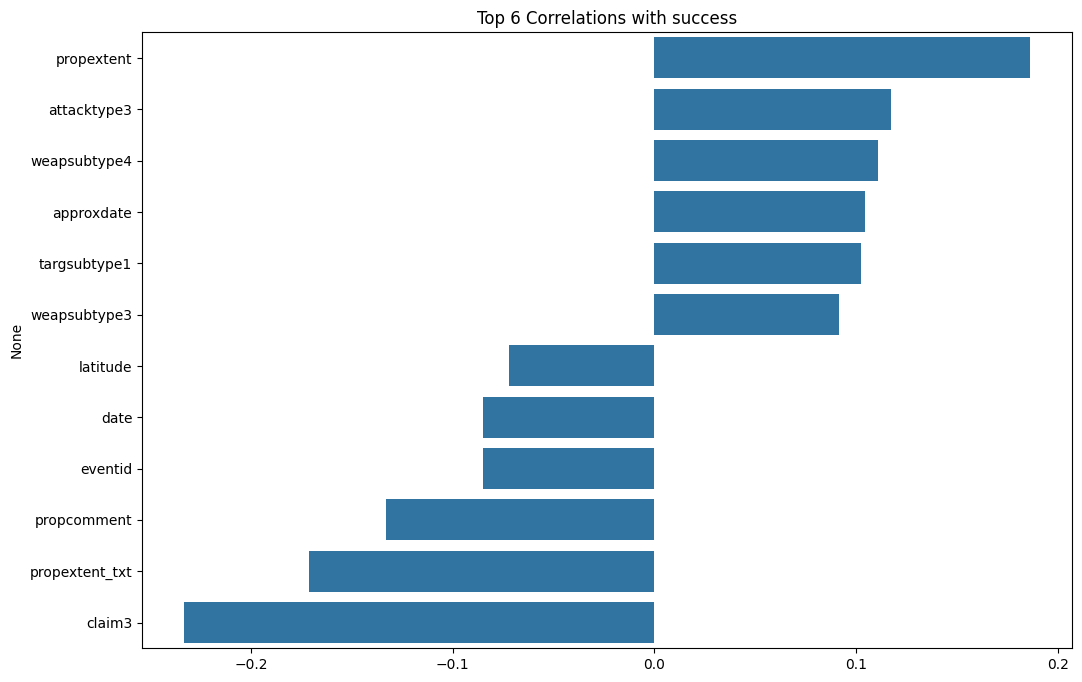

In [233]:
def visualize_top_correlations(data, target_col, top_n=6):
    correlation = data.corr()[target_col].sort_values(ascending=False)
    top_positive = correlation.head(top_n + 1).iloc[1:]
    top_negative = correlation.tail(top_n)

    top_correlations = pd.concat([top_positive, top_negative])

    plt.figure(figsize=(12, 8))
    sns.barplot(x=top_correlations.values, y=top_correlations.index)
    plt.title(f'Top {top_n} Correlations with {target_col}')
    plt.show()

target_column = 'success'
visualize_top_correlations(data, target_column)

# **What we're seeing is that if an attack messes up property, it's more likely to be seen as "successful." Also, if it's confusing who did it, it's weirdly more successful too, like they got away with it. On the flip side, if a bunch of groups are all trying to take credit, or if they try to do too many different things at once, the attack usually flops. And it's kinda strange, but if they had a really clear plan, it's less likely to work. So, what this means is, we need to really protect important buildings and figure out who these sneaky groups are. But, we also gotta remember, just because these things go together, doesn't mean one causes the other. There could be other stuff going on too, like politics or bad data.**